# 評估目標

::: {.callout-tip}

投影片操作：**Alt + 點擊** 可縮放任何圖片/表格（reveal.js zoom）；`O` 鍵總覽、`F` 全螢幕。

:::

**研究提問**：是否存在「機器學習配對 + 深度學習交易」策略，績效優於 SSD/DTW 距離法基準，且年化報酬 $\ge 2\%$？

**資料處理原則**：

- 現役策略清單**動態讀自** 策略設定——陣容變動時本筆記本自動同步，無需手改白名單
- 回測結果資料庫 保留已封存策略的歷史結果，以現役 `db_method` 白名單過濾
- 同一網格鍵若重跑產生多筆，保留最新一筆（防禦性去重）
- 現役但尚無回測數據者（如剛加入的策略）明列為「待回測」
- 所有指標定義與公式見下節「績效指標定義」，與 儀表板績效計算 實作一致


# 績效指標定義與公式

以下全部指標由 儀表板績效計算 計算。
記號：組合每日損益 $\Delta_t$（各配對 `Daily_Delta` 加總）、初始資本 $C_0 = 10{,}000$、
權益 $E_t = C_0 + \sum_{s \le t}\Delta_s$、期末總損益 $\text{PnL} = E_{\text{end}} - C_0$。


## 一、報酬類 {.smaller}

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `Final_Equity` | 期末權益 | $E_{\text{end}} = C_0 + \text{PnL}$ | 回測結束時的組合總值 |
| `Cum_Ret_Raw` | 累積報酬 | $\prod_{m}(1 + r_m) - 1$，$r_m$＝**月末權益**的月報酬 | 全期總報酬（幾何連乘，計複利） |
| `Ann_Ret_Raw` | 年化報酬 | $(1 + \text{Cum\_Ret})^{12/n_{\text{months}}} - 1$ | 幾何年化；**論文主要報酬口徑**、2% 門檻的判準 |

> 月末權益以 `resample("ME").last()` 取得；年化用幾何法（非算術），對複利與時間長度一致。


## 二、風險調整報酬類 {.smaller}

日報酬定義：$r_t = \Delta_t / E_{t-1}$（以前一日真實權益為分母，首日分母補 $C_0$）。

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `Sharpe_Raw` | 夏普比率 | $\sqrt{252}\cdot \dfrac{\overline{r_t}}{\sigma(r_t)}$ | 每單位**總波動**的超額報酬（本口徑 $r_f=0$，未扣無風險利率） |
| `Sortino_Raw` | 索提諾比率 | $\sqrt{252}\cdot \dfrac{\overline{r_t}}{\sigma(r_t^{-})}$，$r_t^{-}$＝負報酬 | 只罰**下行波動**，對稱波動不計入風險 |
| `Calmar_Raw` | 卡瑪比率 | $\dfrac{\text{Ann\_Ret}}{\lvert \text{MDD} \rvert}$ | 每單位**最大回撤**的年化報酬，衡量尾部風險效率 |

> $\sqrt{252}$ 為日頻年化因子（252 交易日）。Sharpe 用全體日報酬標準差；Sortino 只用負日報酬標準差。


## 三、風險類 {.smaller}

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `MDD_Raw` | 最大回撤 | $\min_t \dfrac{E_t - \max_{s\le t} E_s}{\max_{s\le t} E_s}$ | 權益自歷史高點的最大跌幅（負值，越接近 0 越好） |

> 以真實動態權益的滾動最高點計算，非以初始資本為基準。


## 四、交易品質類 {.smaller}

「一筆交易」＝同一配對維持同一持倉方向的一個區段（以 `Position` 變動切段），其損益為該區段 `Daily_Delta` 加總。

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `Win_Rate` | 勝率 | 獲利交易數 / 總交易數 | 正報酬交易的比例 |
| `Profit_Factor` | 獲利因子 | $\dfrac{\text{Gross\_Profit}}{\lvert \text{Gross\_Loss} \rvert}$ | 毛利對毛損之比，$>1$ 才淨賺 |
| `Gross_Profit` / `Gross_Loss` | 毛利 / 毛損 | 獲利交易損益總和 / 虧損交易損益總和 | 拆解損益來源 |
| `Avg_Trade_Days` | 平均持倉天數 | 平倉交易 `Days_Held` 平均 | 週轉速度 |
| `Entries` / `Exits` | 進場 / 正常出場數 | 持倉方向變動計數 | 交易活躍度 |
| `Stop_Losses` / `Forced_Closes` | 停損 / 期末強平數 | 依 `Status` 分類計數 | 風控觸發頻率 |


## 五、資本效率類（文獻口徑）{.smaller}

配對交易為市場中性、資金非全額動用；下列指標區分「承諾資本」與「實際動用資本」。
$\text{max\_pairs} = \text{Top N} \times$ 重疊期數（6）。

| 指標 | 中文 | 公式 | 意涵 |
| :--- | :--- | :--- | :--- |
| `RCC_Raw` | 承諾資本報酬 | $\text{PnL} / C_0$ | 以固定承諾資本 $C_0$ 計的總報酬 |
| `REC_Raw` | 動用資本報酬 | $\text{PnL} / (n_{\text{traded}} \times C_0/\text{TopN})$ | 以實際交易過的配對資本計 |
| `Avg_Utilization` | 平均資金利用率 | 日均持倉配對數 / max\_pairs | 資金實際動用比例 |
| `Ann_Ret_Employed` | 動用資本年化 | $\text{PnL} / (\text{日均動用資金} \times \text{年數})$ | 只算真正投入資金的年化（GGR fully-invested 口徑） |
| `Excess_Ret_RF` | 無風險超額年化 | 算術年化 $- r_f \times$ 利用率，$r_f=2\%$ | 閒置現金計 $r_f$ 息後的超額 |

> 承諾資本 vs 動用資本的差異反映市場中性策略「帳面報酬率被閒置資金稀釋」的特性——
> `Ann_Ret_Employed` 通常遠高於 `Ann_Ret_Raw`。


# 資料載入與現役陣容


In [1]:
import sqlite3, sys
from pathlib import Path
import pandas as pd
import matplotlib, matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = ["Microsoft JhengHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams.update({"font.size": 14, "figure.dpi": 110})

# 專案根加入 sys.path，動態讀取現役策略清單
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "strategies" / "config.py").exists())
sys.path.insert(0, str(ROOT))
from strategies.config import strategies_raw_all

# 現役 db_method 白名單（排除 formation-only），保留定義順序
ACTIVE = [(s["db_method"], s["trade_method"]) for s in strategies_raw_all if not s.get("formation_only")]
ACTIVE_METHODS = [m for m, _ in ACTIVE]
print(f"現役交易策略 {len(ACTIVE_METHODS)} 個（讀自 strategies/config.py）")

db = ROOT / "results" / "result.db"
raw_df = pd.read_sql("SELECT * FROM strategy_summaries", sqlite3.connect(f"file:{db}?mode=ro", uri=True))
n_archived = (~raw_df["METHOD"].isin(ACTIVE_METHODS)).sum()
df = raw_df[raw_df["METHOD"].isin(ACTIVE_METHODS)].copy()

_grid = ["METHOD", "TOP N", "STOP LOSS %", "MAX SEC %", "ENTRY Z", "DYN Z NUM"]
n0 = len(df); df = df.drop_duplicates(subset=_grid, keep="last").reset_index(drop=True)

have = set(df["METHOD"].unique())
missing = [m for m in ACTIVE_METHODS if m not in have]
print(f"現役網格結果 {len(df)} 筆（去重移除 {n0 - len(df)}）｜排除封存殘留 {n_archived} 筆")
print(f"有數據 {len(have)}/{len(ACTIVE_METHODS)} 策略")
if missing:
    print("待回測（現役但無數據）：")
    for m in missing: print(f"  - {m}")


現役交易策略 12 個（讀自 strategies/config.py）
現役網格結果 180 筆（去重移除 135）｜排除封存殘留 420 筆
有數據 12/12 策略


## 總表：現役策略績效總覽

每列為該策略在所有網格配置中 **Sharpe 最高** 的一組，依 Sharpe 由高到低排序。年化採「動用資金」口徑（排除閒置現金）；強平率 ＝ 期末強制平倉次數 ÷ 進場次數。

In [2]:
import numpy as np
_m = ['METHOD','TRADE_METHOD','TOP N','STOP LOSS %','Ann_Ret_Employed','Sharpe_Raw',
      'MDD_Raw','Calmar_Raw','Profit_Factor','Win_Rate','Forced_Closes','Entries']
best = df.loc[df.groupby('METHOD')['Sharpe_Raw'].idxmax(), _m].copy()
best['強平率'] = best['Forced_Closes'] / best['Entries'].replace(0, np.nan)
best['配置'] = best['TOP N'].astype(str).str.replace('Top ', 'T') + '/' + best['STOP LOSS %'].astype(str)
summary = best.sort_values('Sharpe_Raw', ascending=False).reset_index(drop=True)
summary.insert(0, '#', range(1, len(summary) + 1))
_show = summary[['#','METHOD','TRADE_METHOD','配置','Ann_Ret_Employed','Sharpe_Raw',
                 'MDD_Raw','Calmar_Raw','Profit_Factor','Win_Rate','強平率']]
_show.columns = ['#','策略','交易法','配置','年化(動用)','Sharpe','最大回撤','Calmar','獲利因子','勝率','強平率']
(_show.style
   .format({'年化(動用)':'{:.2%}','Sharpe':'{:.3f}','最大回撤':'{:.2%}','Calmar':'{:.2f}',
            '獲利因子':'{:.2f}','勝率':'{:.1%}','強平率':'{:.1%}'})
   .background_gradient(subset=['Sharpe'], cmap='RdYlGn')
   .hide(axis='index'))

#,策略,交易法,配置,年化(動用),Sharpe,最大回撤,Calmar,獲利因子,勝率,強平率
1,DTW,Z-Score,T20/15%,4.16%,0.817,-3.12%,0.58,1.19,33.6%,12.0%
2,Agglomerative (FMP),Z-Score,T1/0%,5.89%,0.356,-24.20%,0.09,1.35,30.6%,31.3%
3,Agglomerative (FMP·DRL),DRL,T1/15%,5.16%,0.326,-23.53%,0.10,1.32,46.1%,22.0%
4,SSD (DRL),DRL,T5/0%,2.31%,0.309,-9.88%,0.09,1.11,36.1%,6.0%
5,Agglomerative (yF·DRL),DRL,T1/15%,5.49%,0.278,-23.92%,0.10,1.34,45.0%,19.9%
6,SSD (Distance),Distance,T1/0%,3.07%,0.216,-26.59%,0.06,1.19,33.6%,27.6%
7,Agglomerative (yF),Z-Score,T1/0%,2.56%,0.204,-25.65%,0.06,1.16,35.9%,23.5%
8,SSD (Rolling),Z-Score,T1/0%,3.04%,0.203,-23.74%,0.07,1.19,33.9%,24.6%
9,HDBSCAN (殘差),Z-Score,T10/0%,0.85%,0.168,-16.78%,0.03,1.05,32.6%,34.6%
10,SSD-DTW-PCA,Z-Score,T20/15%,0.54%,0.144,-6.92%,0.04,1.03,33.1%,14.6%


## 年化績效（動用資金口徑）

各策略最佳配置的年化報酬，由高到低；紅色為負。

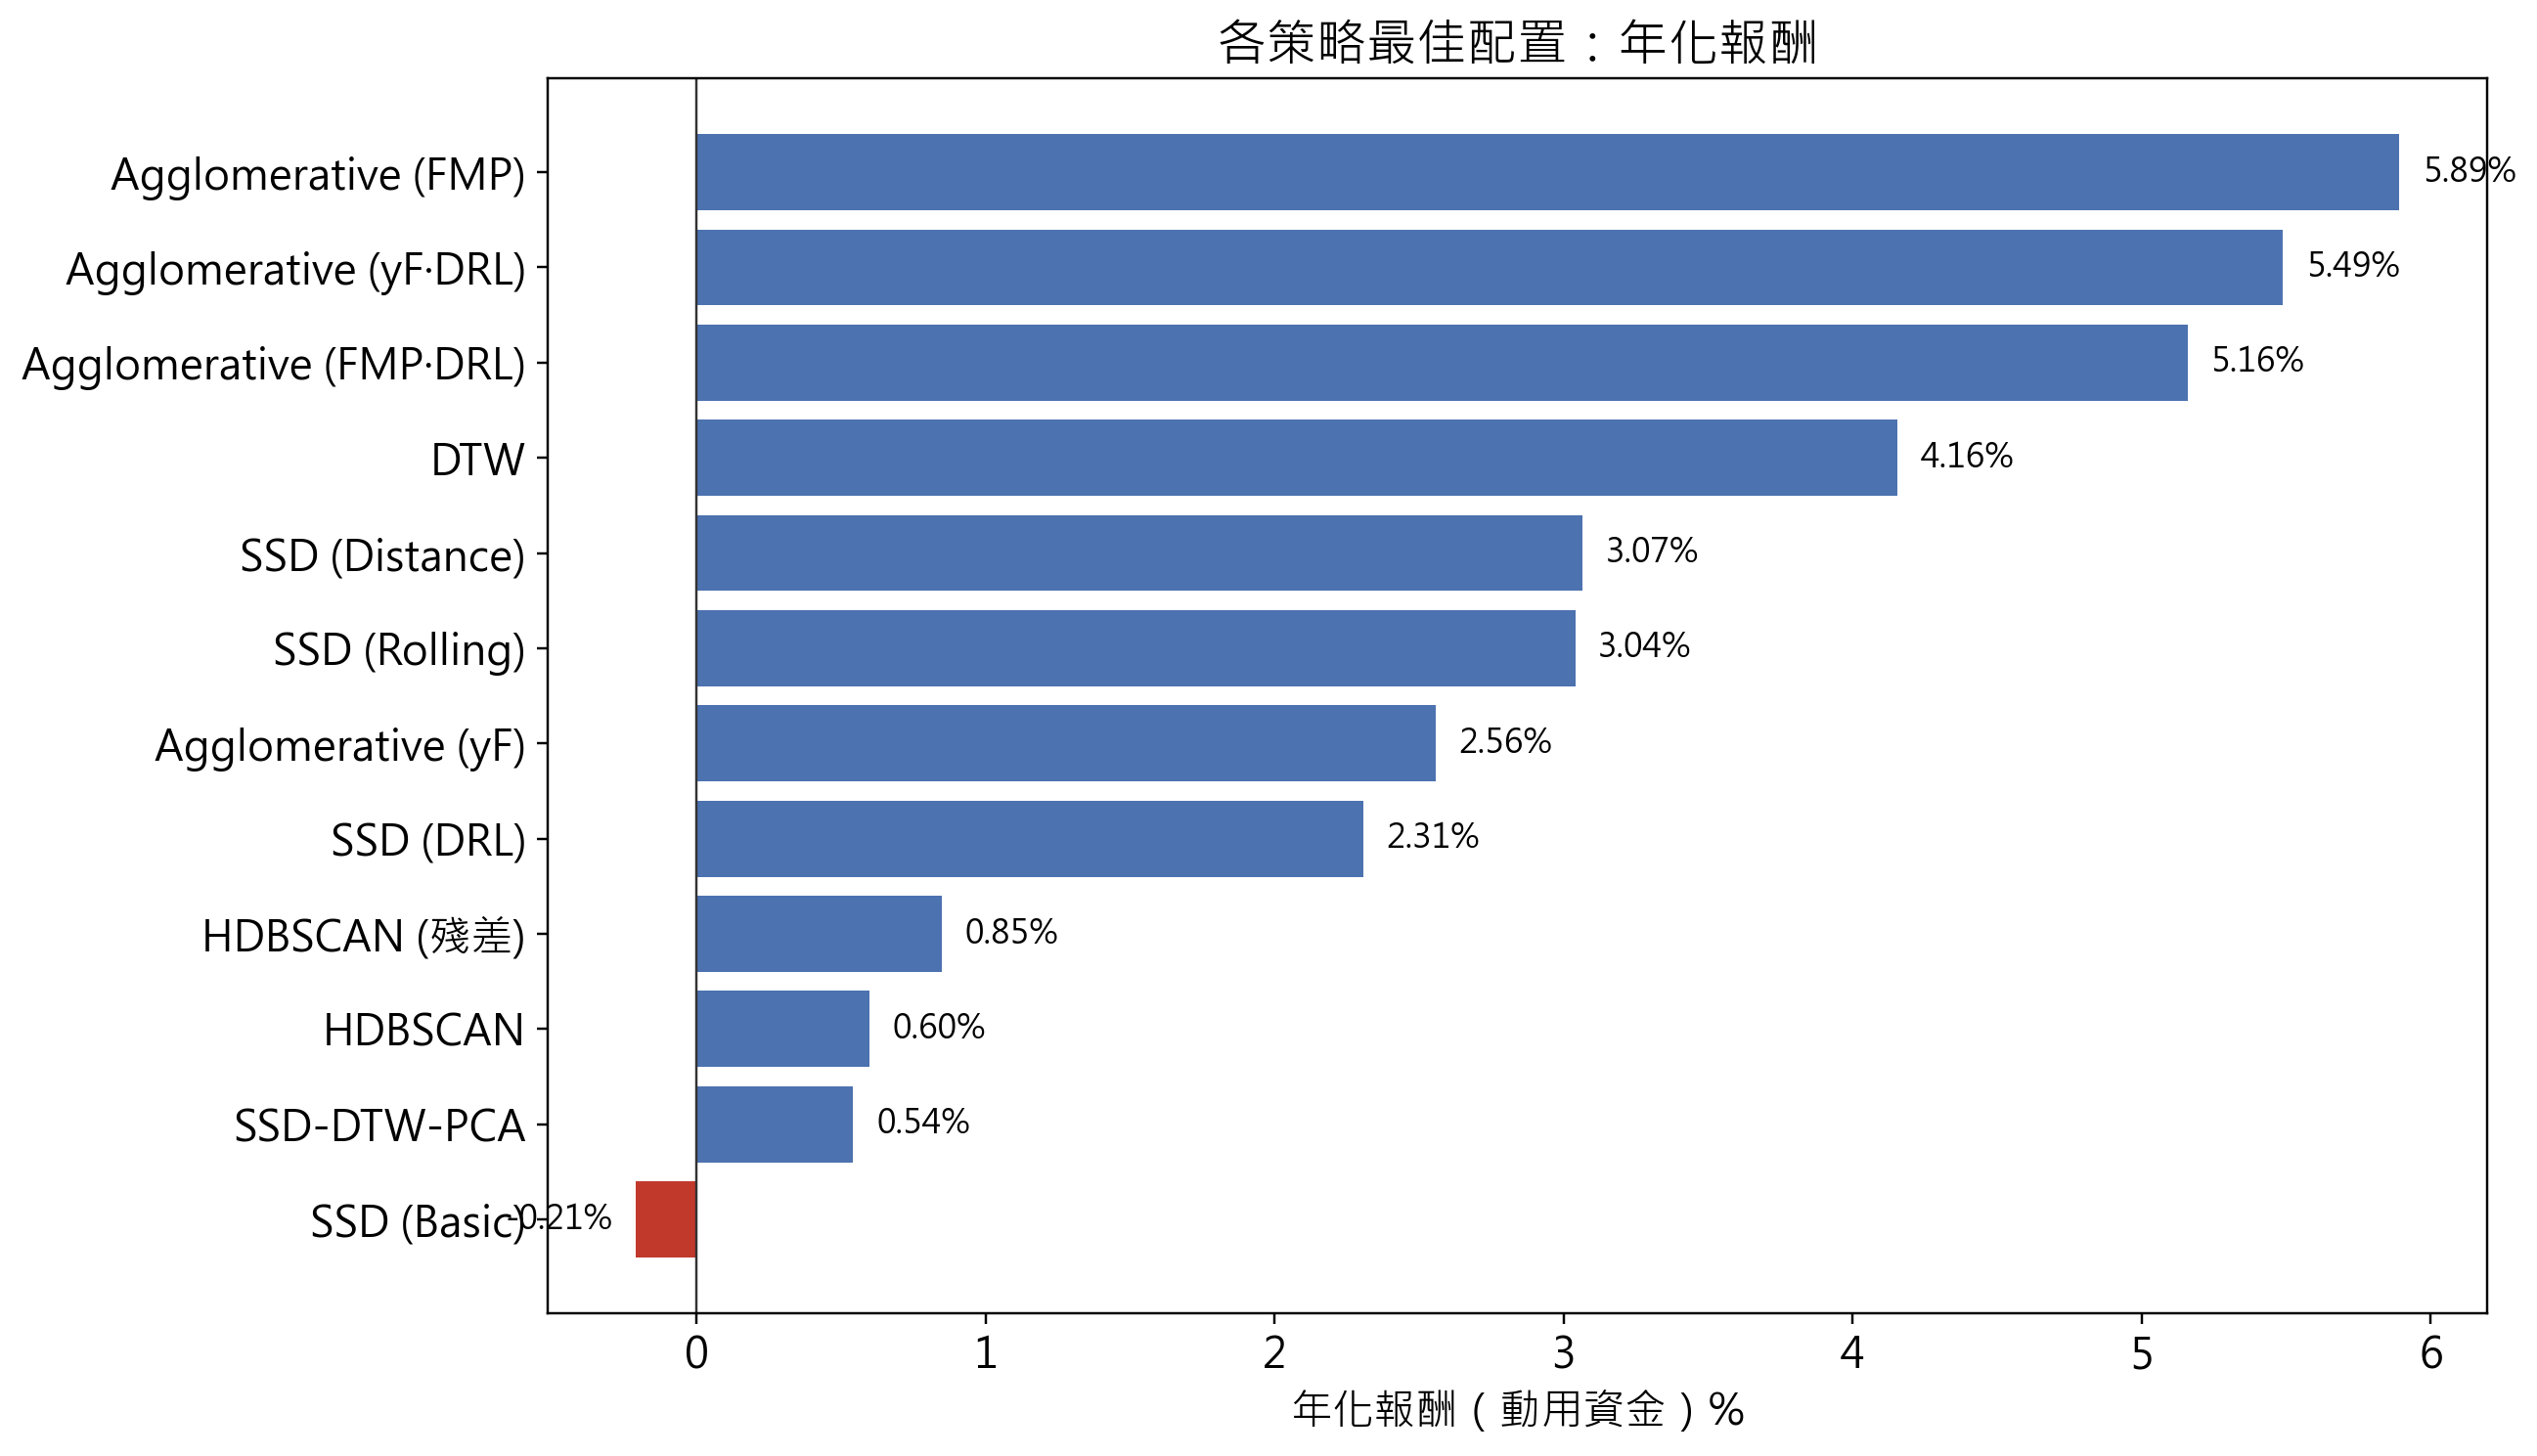

In [3]:
d = summary.sort_values('Ann_Ret_Employed')
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(d['METHOD'], d['Ann_Ret_Employed'] * 100,
        color=['#c0392b' if v < 0 else '#4c72b0' for v in d['Ann_Ret_Employed']])
ax.axvline(0, color='#333', lw=0.8)
ax.set_xlabel('年化報酬（動用資金）%'); ax.set_title('各策略最佳配置：年化報酬')
for i, v in enumerate(d['Ann_Ret_Employed'] * 100):
    ax.text(v + (0.08 if v >= 0 else -0.08), i, f'{v:.2f}%',
            va='center', ha='left' if v >= 0 else 'right', fontsize=11)
plt.tight_layout(); plt.show()

## Sharpe 績效

各策略最佳配置的 Sharpe（$\sqrt{252}\cdot\bar r/\sigma_r$，$r_f=0$）；紅色為負。

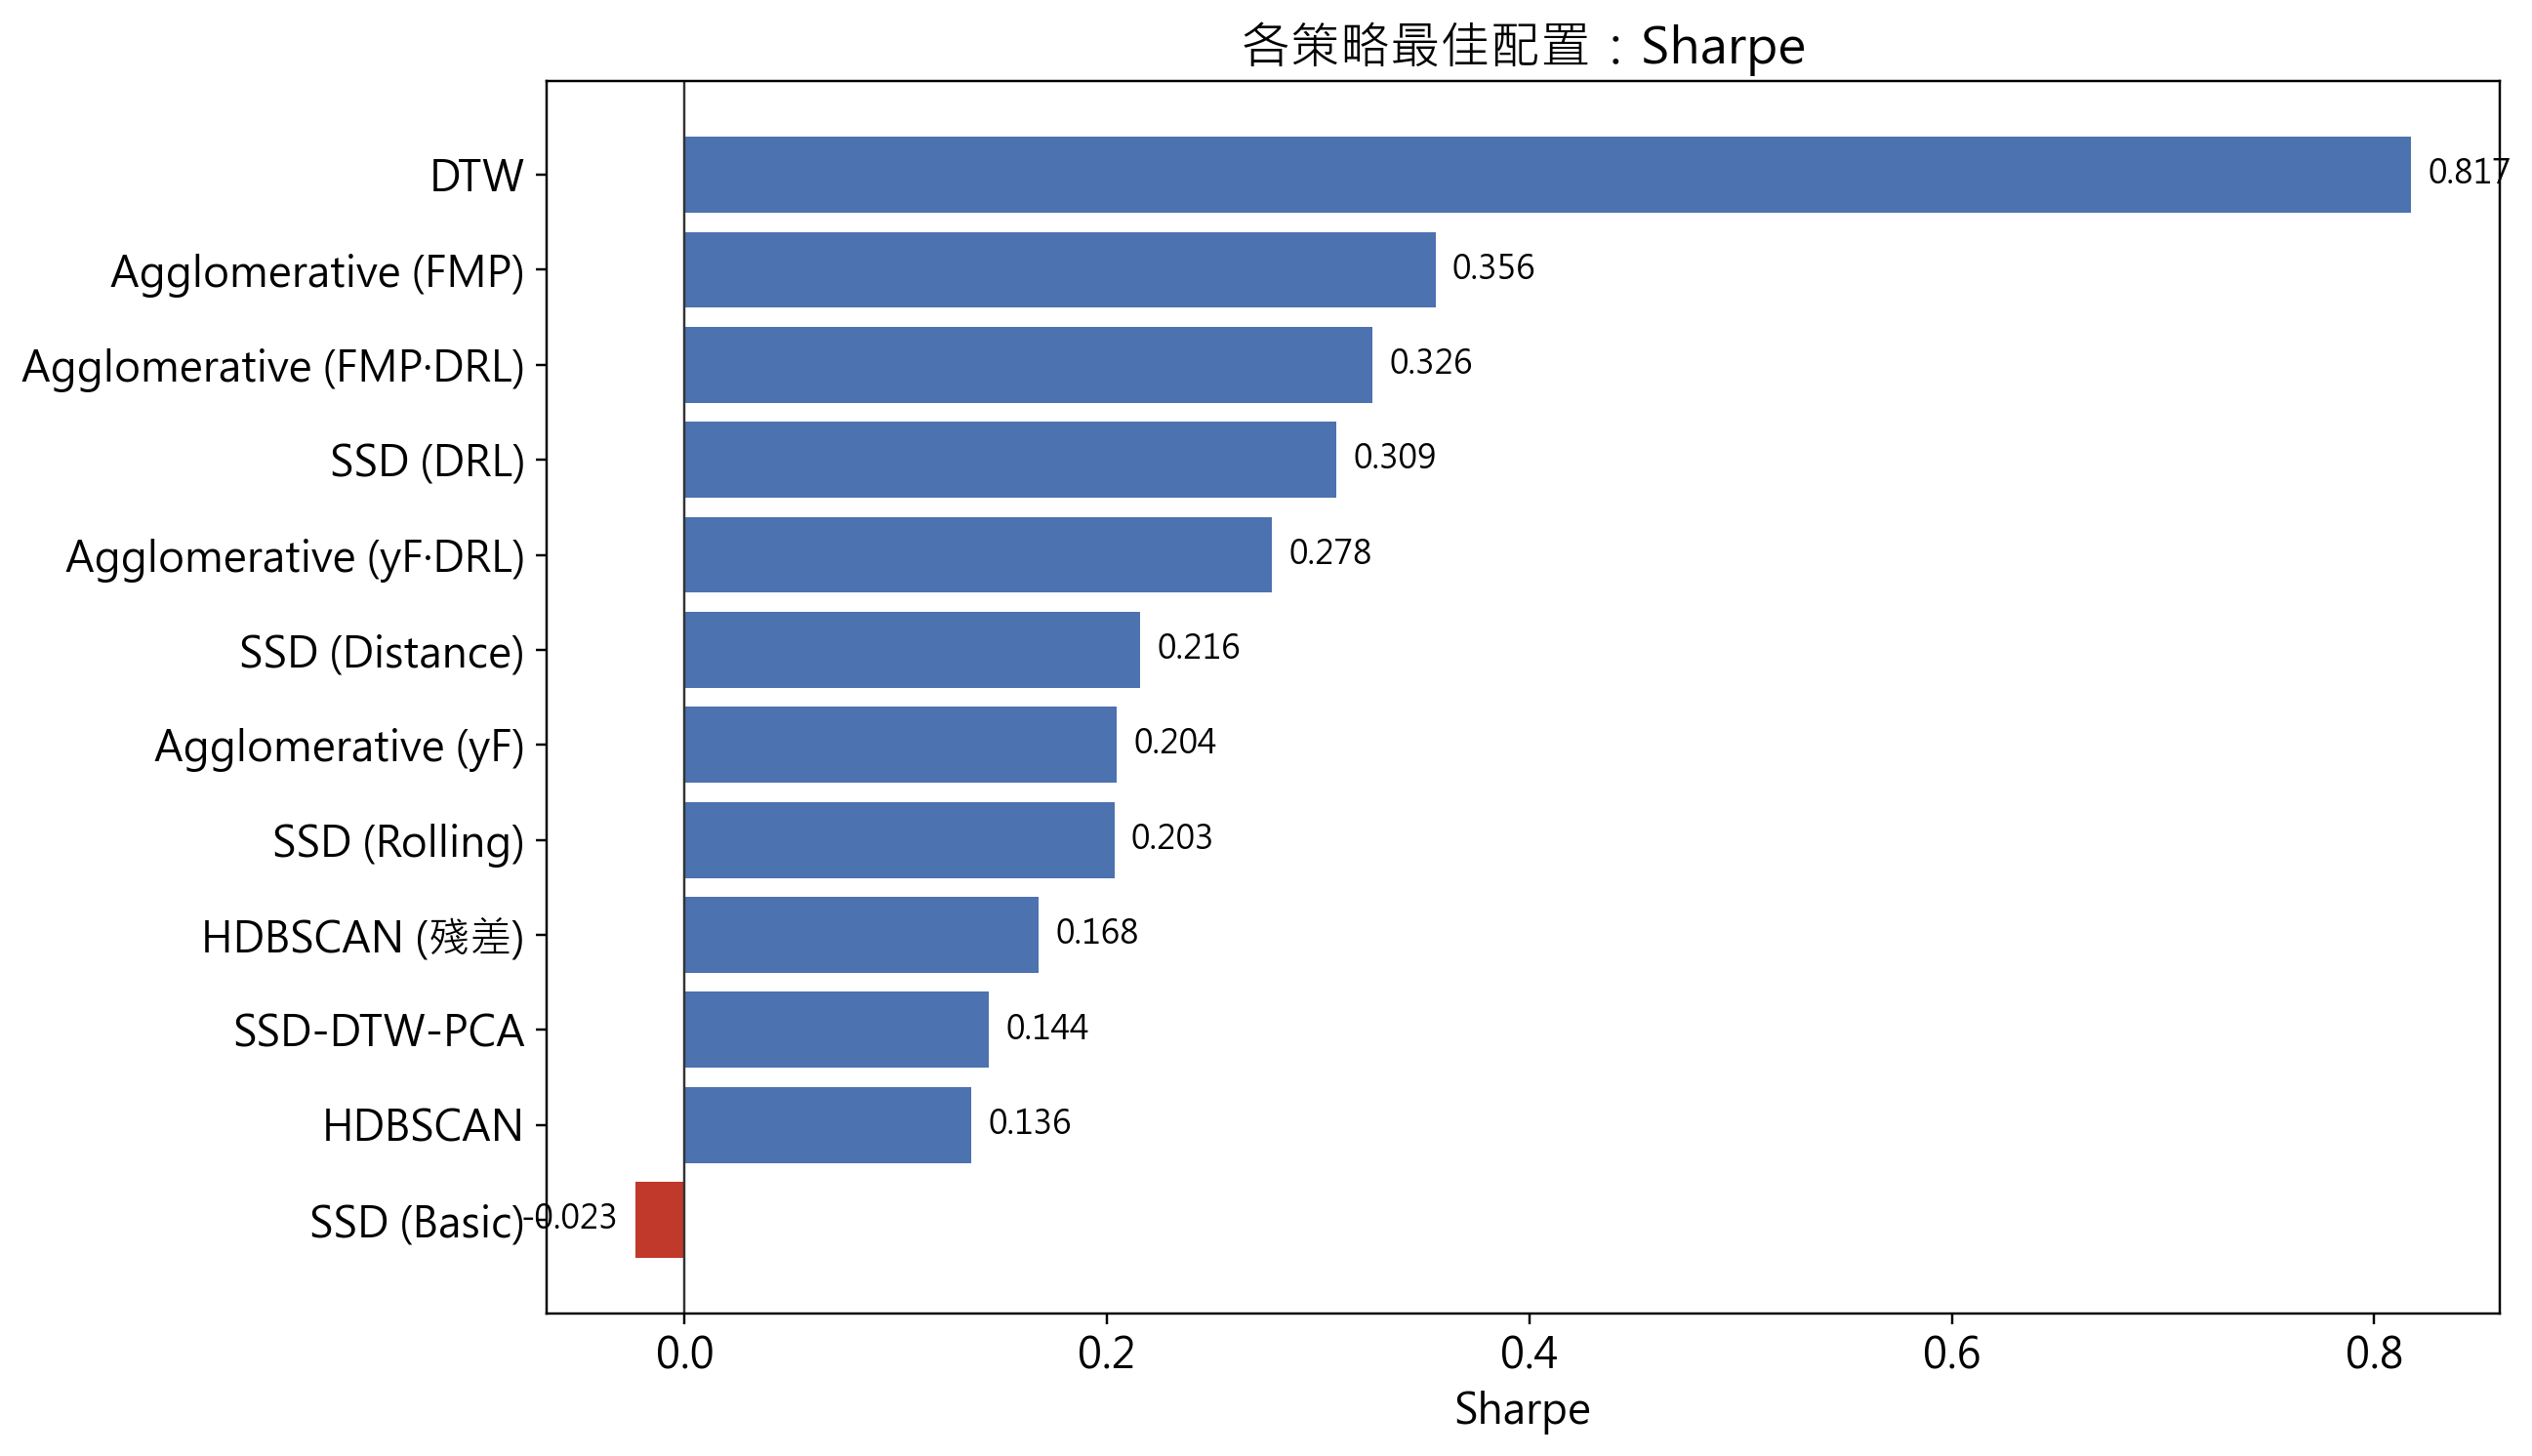

In [4]:
d = summary.sort_values('Sharpe_Raw')
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(d['METHOD'], d['Sharpe_Raw'],
        color=['#c0392b' if v < 0 else '#4c72b0' for v in d['Sharpe_Raw']])
ax.axvline(0, color='#333', lw=0.8)
ax.set_xlabel('Sharpe'); ax.set_title('各策略最佳配置：Sharpe')
for i, v in enumerate(d['Sharpe_Raw']):
    ax.text(v + (0.008 if v >= 0 else -0.008), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=11)
plt.tight_layout(); plt.show()

## 最大回撤

各策略最佳配置的最大回撤（$\min_t (E_t-\max_{s\le t}E_s)/\max_{s\le t}E_s$）；越接近 0 越好。

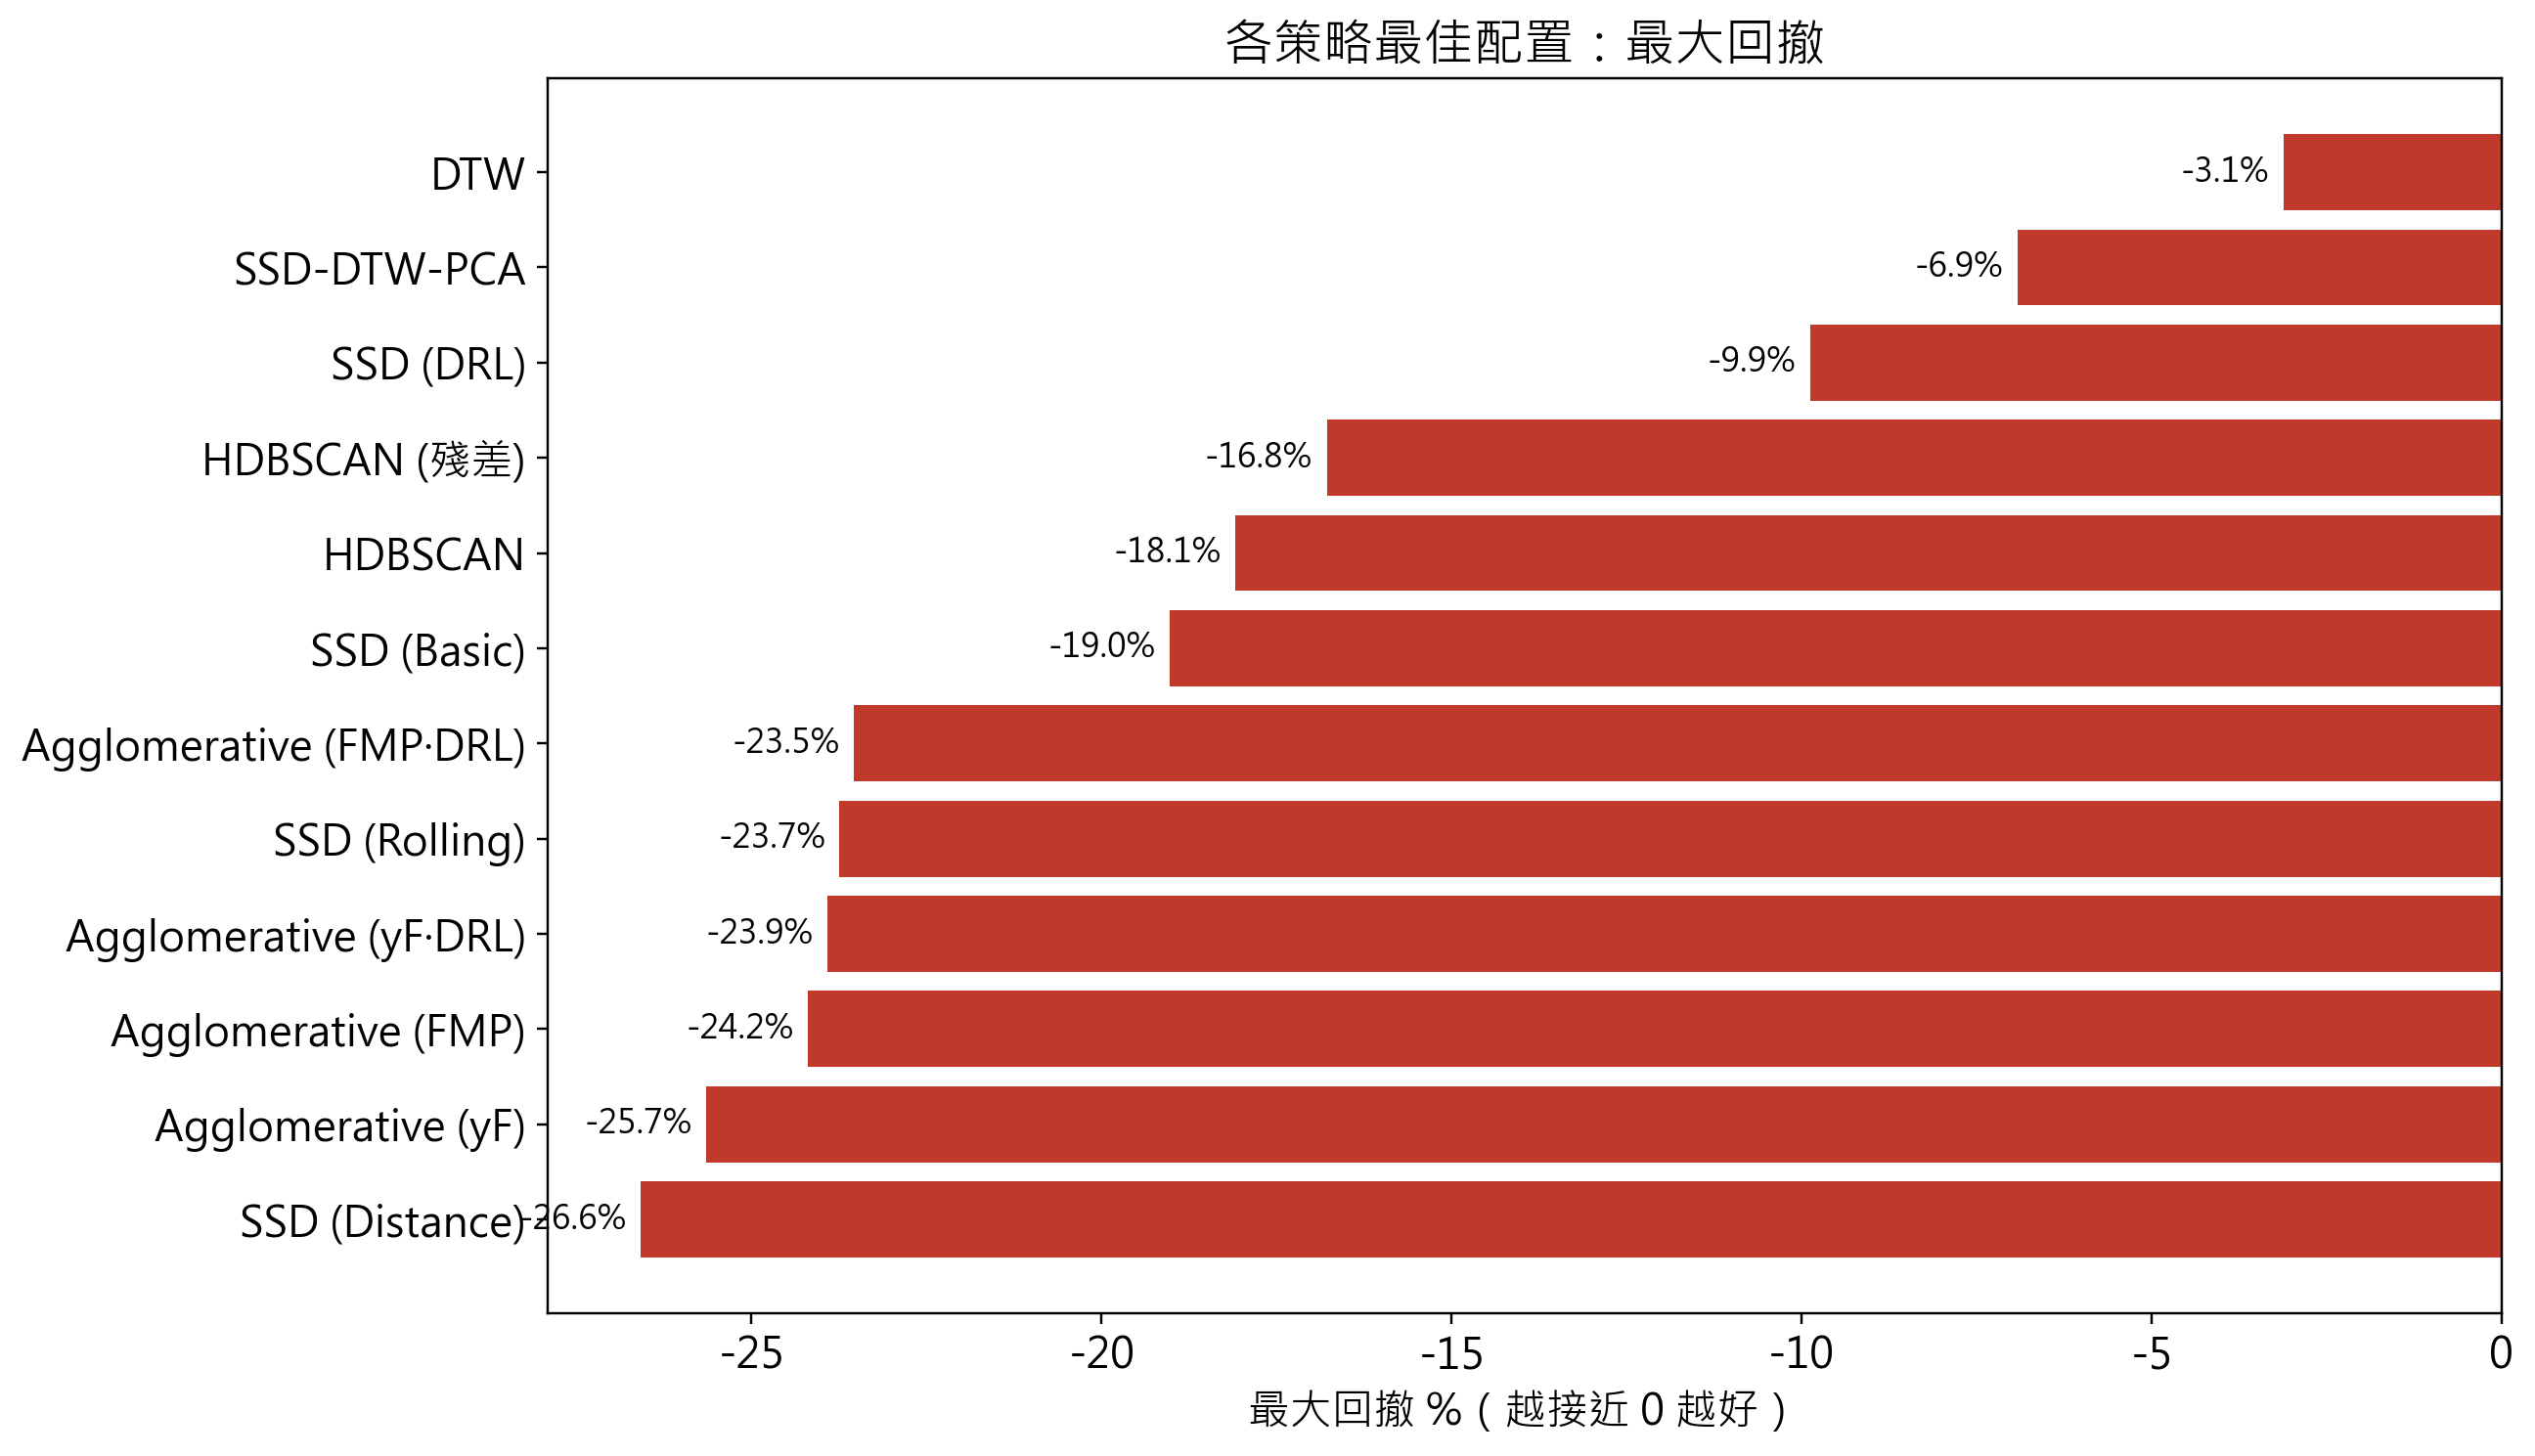

In [5]:
d = summary.sort_values('MDD_Raw')
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(d['METHOD'], d['MDD_Raw'] * 100, color='#c0392b')
ax.set_xlabel('最大回撤 %（越接近 0 越好）'); ax.set_title('各策略最佳配置：最大回撤')
for i, v in enumerate(d['MDD_Raw'] * 100):
    ax.text(v - 0.2, i, f'{v:.1f}%', va='center', ha='right', fontsize=11)
plt.tight_layout(); plt.show()

## Sharpe × 年化報酬散佈（全網格）


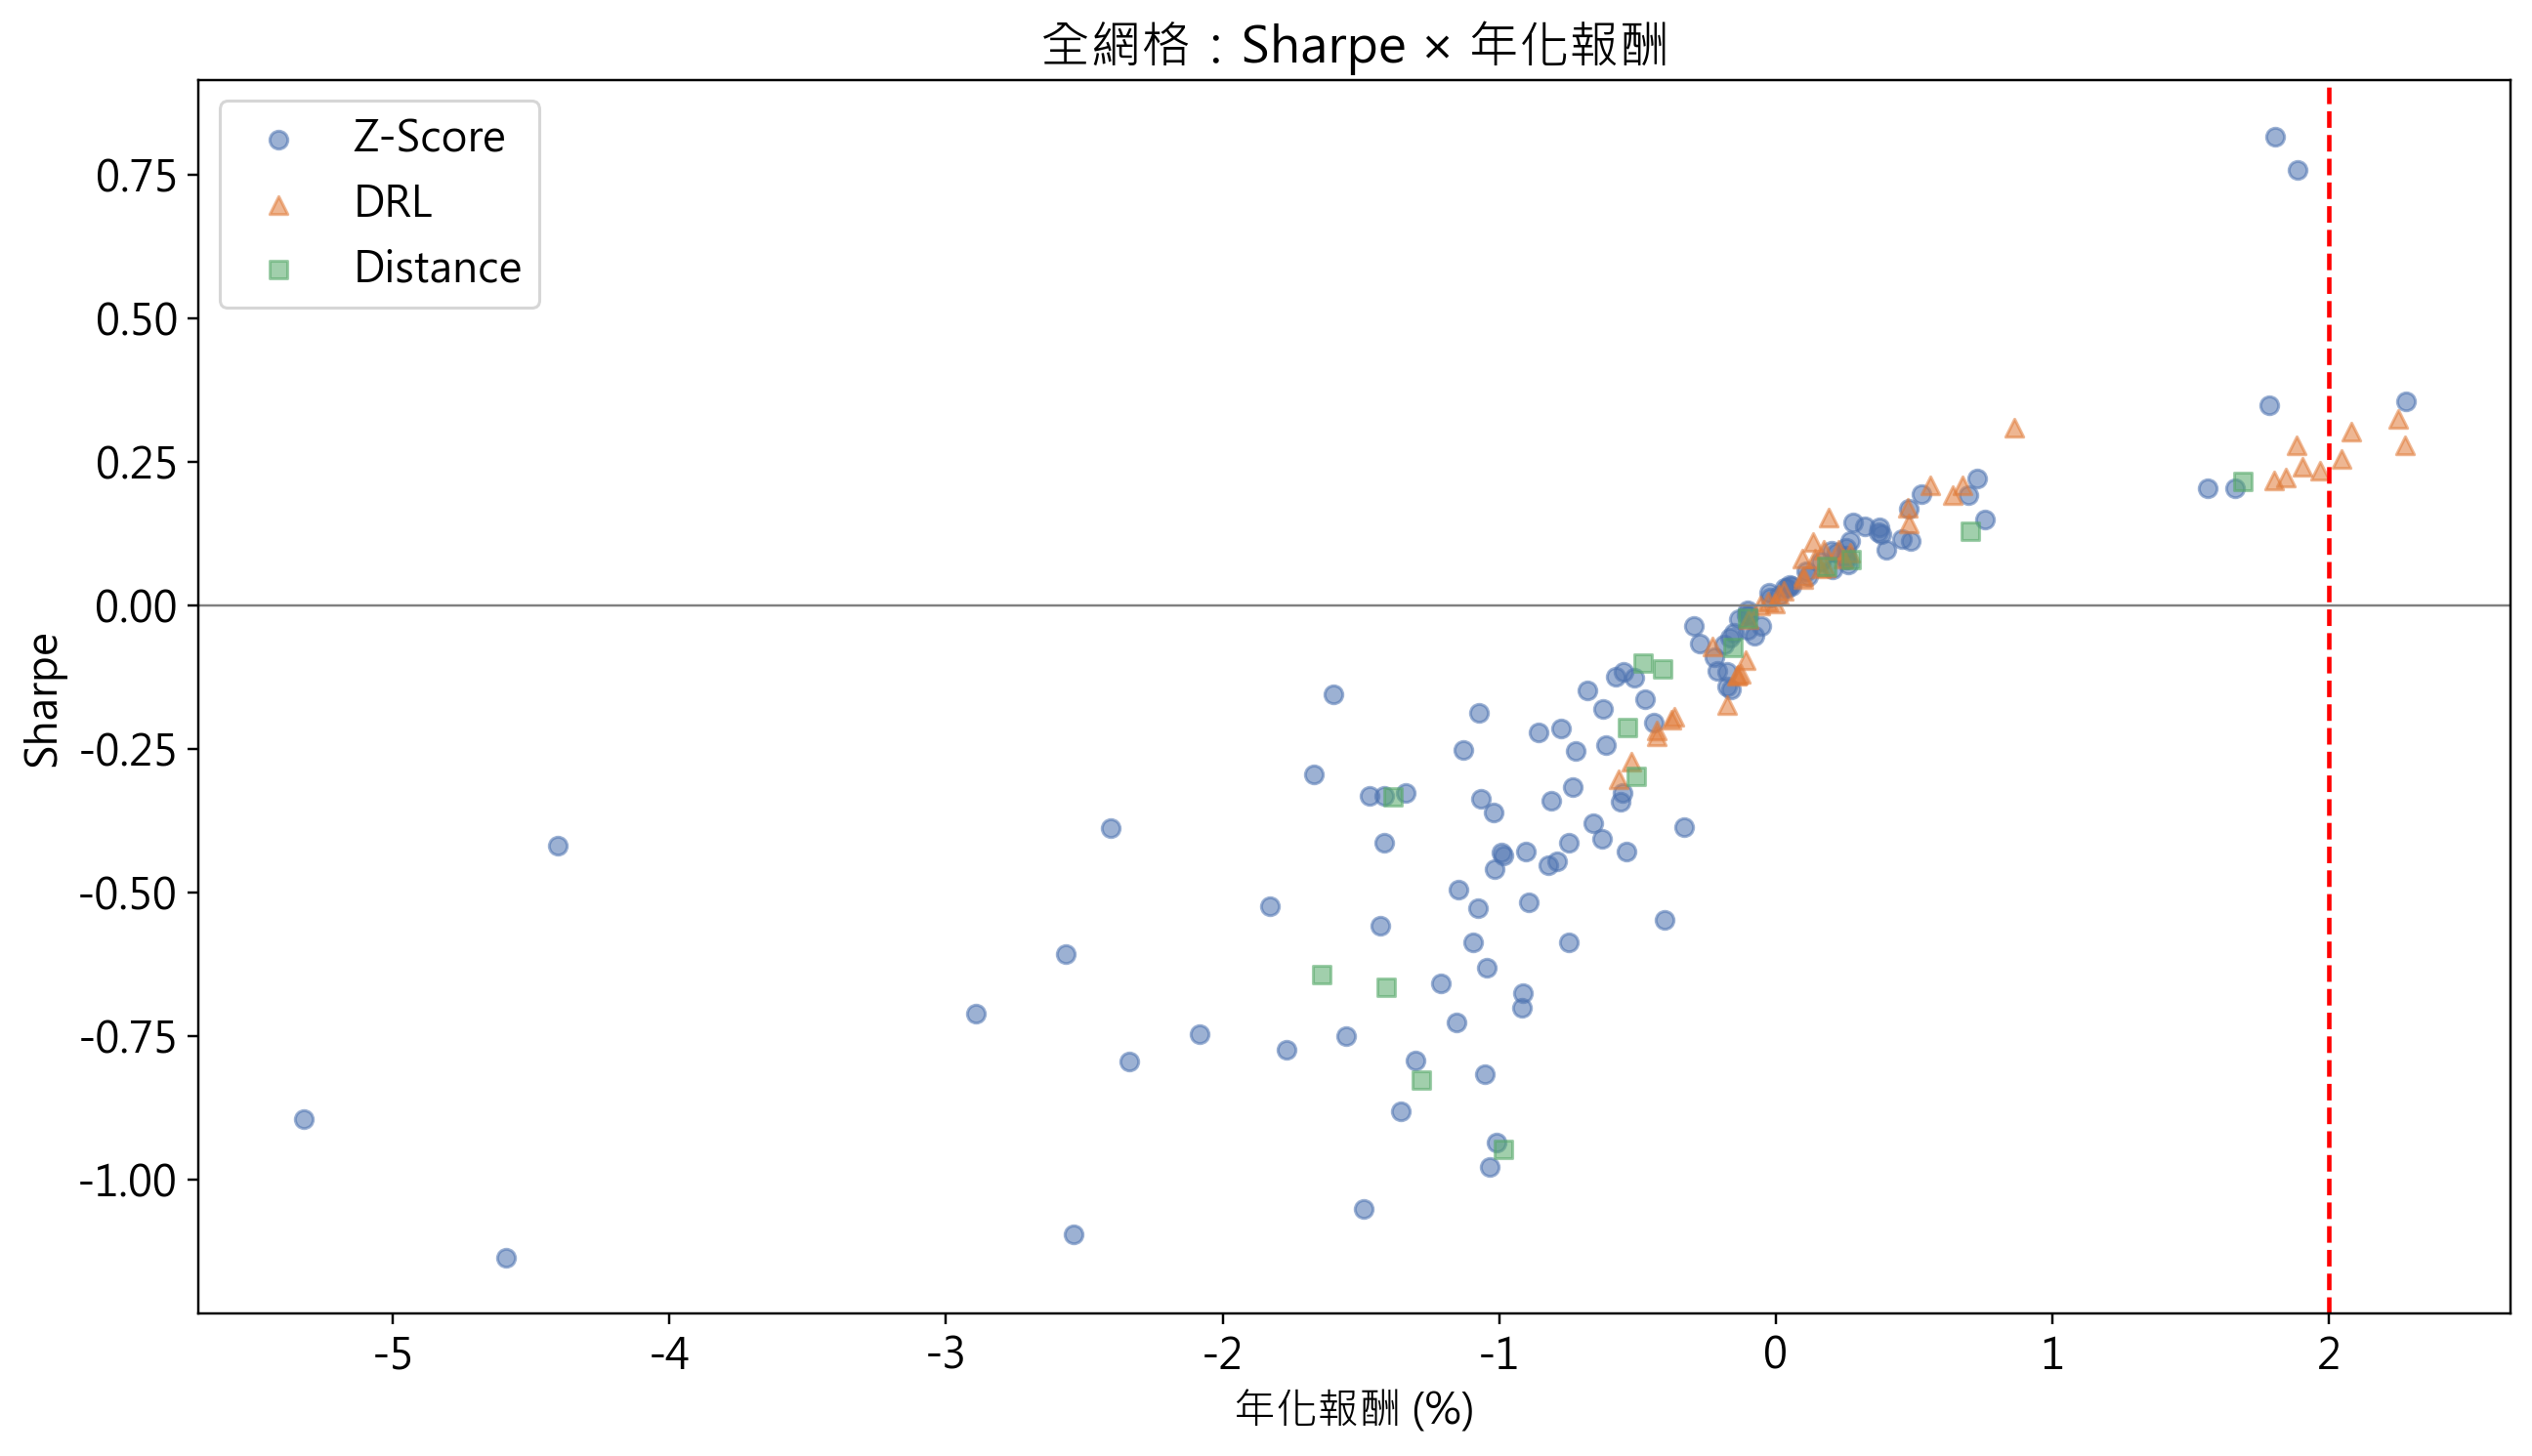

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
for tm, c, mk in [("Z-Score","#4c72b0","o"),("DRL","#e07b39","^"),("Distance","#55a868","s")]:
    sub = df[df["TRADE_METHOD"] == tm]
    if not sub.empty:
        ax.scatter(sub["Ann_Ret_Raw"]*100, sub["Sharpe_Raw"], c=c, marker=mk, alpha=0.55, label=tm)
ax.axvline(2.0, color="red", ls="--", lw=1.5); ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("年化報酬 (%)"); ax.set_ylabel("Sharpe"); ax.set_title("全網格：Sharpe × 年化報酬")
ax.legend(); plt.tight_layout(); plt.show()


## 單變因對照

現役設計了兩組乾淨的單變因消融——形成期配對相同、僅改交易決策邏輯。


In [7]:
def _best(m, col="Sharpe_Raw"):
    s = df[df["METHOD"] == m]
    return (s["Sharpe_Raw"].max(), s["Ann_Ret_Raw"].max()) if not s.empty else (None, None)

# (A) 回歸 vs 距離：SSD Rolling
# (B) Z-Score vs DRL 疊加
pairs = [
    ("回歸 vs 距離", "SSD (Rolling)", "SSD (Distance)"),
    ("Z vs DRL：SSD", "SSD (Rolling)", "SSD (DRL)"),
    ("Z vs DRL：Agglo(yF)", "Agglomerative (yF)", "Agglomerative (yF·DRL)"),
    ("Z vs DRL：Agglo(FMP)", "Agglomerative (FMP)", "Agglomerative (FMP·DRL)"),
]
rows = []
for label, a, b in pairs:
    sa, ra = _best(a); sb, rb = _best(b)
    if sa is None or sb is None: continue
    rows.append({"對照": label, "基準": a.split("(")[-1].rstrip(")"), "變體": b.split("(")[-1].rstrip(")"),
                 "Sharpe 基準": sa, "Sharpe 變體": sb, "ΔSharpe": sb-sa,
                 "年化 基準": ra, "年化 變體": rb, "Δ年化": rb-ra})
pd.DataFrame(rows).style.format({"Sharpe 基準":"{:.3f}","Sharpe 變體":"{:.3f}","ΔSharpe":"{:+.3f}",
                                 "年化 基準":"{:.2%}","年化 變體":"{:.2%}","Δ年化":"{:+.2%}"})


,對照,基準,變體,Sharpe 基準,Sharpe 變體,ΔSharpe,年化 基準,年化 變體,Δ年化
0,回歸 vs 距離,Rolling,Distance,0.203,0.216,+0.012,1.66%,1.69%,+0.03%
1,Z vs DRL：SSD,Rolling,DRL,0.203,0.309,+0.105,1.66%,1.97%,+0.31%
2,Z vs DRL：Agglo(yF),yF,yF·DRL,0.204,0.278,+0.074,1.56%,2.28%,+0.72%
3,Z vs DRL：Agglo(FMP),FMP,FMP·DRL,0.356,0.326,-0.030,2.28%,2.25%,-0.03%


## DRL-THR 訓練變異數：多輪獨立重跑分布

`strategy_summaries` 只存最後一輪；DRL-THR 未固定隨機種子，
下列統計取自 多輪重跑統計（多輪重跑程序 多輪完整網格重跑），
**這才是 DRL 策略應引用的正式數字（中位數 ± 範圍）**。


In [8]:
cand = [ROOT/"results"/"analysis"/"drl_variance_runs.csv", ROOT/"results"/"drl_variance_runs.csv"]
var_csv = next((x for x in cand if x.exists()), None)
drl_active = [m for m, t in ACTIVE if t == "DRL"]
if var_csv is not None:
    runs = pd.read_csv(var_csv)
    ra = runs[runs["METHOD"].isin(ACTIVE_METHODS)].copy()
    covered = set(ra["METHOD"].unique())
    if not ra.empty:
        per = (ra.groupby(["METHOD","run_id"]).agg(bs=("Sharpe_Raw","max"), br=("Ann_Ret_Raw","max")).reset_index())
        summ = (per.groupby("METHOD").agg(輪數=("run_id","nunique"),
                Sharpe中位=("bs","median"), Sharpe最小=("bs","min"), Sharpe最大=("bs","max"),
                年化中位=("br","median"), 年化最小=("br","min"), 年化最大=("br","max")).reset_index())
        display(summ.style.format({"Sharpe中位":"{:.3f}","Sharpe最小":"{:.3f}","Sharpe最大":"{:.3f}",
                                   "年化中位":"{:.2%}","年化最小":"{:.2%}","年化最大":"{:.2%}"}))
    else:
        print("variance CSV 中無對得上現役命名的 DRL 策略")
    stale = [m for m in drl_active if m not in covered]
    if stale:
        print("下列現役 DRL 策略的變異數分析尚待以新命名重跑 run_drl_variance.py：")
        for m in stale:
            print("  - " + m)
    print("（variance CSV：" + str(var_csv.relative_to(ROOT)) + "）")
else:
    print("尚無 drl_variance_runs.csv")


variance CSV 中無對得上現役命名的 DRL 策略
下列現役 DRL 策略的變異數分析尚待以新命名重跑 run_drl_variance.py：
  - SSD (DRL)
  - Agglomerative (yF·DRL)
  - Agglomerative (FMP·DRL)
（variance CSV：results\analysis\drl_variance_runs.csv）


## 達標檢核（動態產生）


In [9]:
best_ann = df.loc[df.groupby("METHOD")["Ann_Ret_Employed"].idxmax()].sort_values("Ann_Ret_Employed", ascending=False)
passed = best_ann[best_ann["Ann_Ret_Employed"] >= 0.02]
print("年化（動用資金）跨過 2% 門檻的策略：")
for _, r in passed.iterrows():
    print(f"  {r['METHOD']:<45s} 年化 {r['Ann_Ret_Employed']:.2%}｜Sharpe {r['Sharpe_Raw']:.3f}｜{r['TRADE_METHOD']}")
ts = summary.iloc[0]
print(f"\n全組最高 Sharpe：{ts['METHOD']}（{ts['Sharpe_Raw']:.3f}，年化(動用) {ts['Ann_Ret_Employed']:.2%}）")

年化（動用資金）跨過 2% 門檻的策略：
  Agglomerative (FMP)                           年化 5.89%｜Sharpe 0.356｜Z-Score
  Agglomerative (yF·DRL)                        年化 5.49%｜Sharpe 0.278｜DRL
  Agglomerative (FMP·DRL)                       年化 5.16%｜Sharpe 0.326｜DRL
  SSD (DRL)                                     年化 4.40%｜Sharpe 0.234｜DRL
  DTW                                           年化 4.16%｜Sharpe 0.817｜Z-Score
  SSD (Distance)                                年化 3.07%｜Sharpe 0.216｜Distance
  SSD (Rolling)                                 年化 3.04%｜Sharpe 0.203｜Z-Score
  Agglomerative (yF)                            年化 2.56%｜Sharpe 0.204｜Z-Score

全組最高 Sharpe：DTW（0.817，年化(動用) 4.16%）


## 解讀注意事項 {.smaller}

- **指標口徑**：Sharpe/Sortino 以 $r_f = 0$ 計（未扣無風險利率）；年化報酬為幾何口徑。
  資本效率類（`Ann_Ret_Employed`、`Excess_Ret_RF`）才計入 $r_f = 2\%$ 與資金利用率，數值與 `Ann_Ret_Raw` 不可混用比較
- **SSD Basic**：2026-07-06 起為 Gatev/Zhu 論文復刻版（全市場、純距離、無統計過濾），此日期前歷史數據為舊版演算法，不可跨版本比較
- **Agglomerative yF vs FMP**：yF 為單一時點快照（有前視偏誤），FMP 為 Point-in-Time 逐點（已修正前視）——比較時須一併考量資料口徑差異
- **DRL-THR 系**：未固定隨機種子，單次數值有重訓波動；絕對數字以 variance CSV 的中位數±範圍為準，跨策略比較以「基準 → 疊加」的相對方向為準
- **待回測策略**：現役但無數據者於上方明列，回測後重新執行本筆記本即自動納入
